<a href="https://colab.research.google.com/github/kaiogva/BIGDATA-PYTHON/blob/main/Conhe%C3%A7a_o_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SEGURANÇA PÚBLICA DE SAQUAREMA (SPS)

Lendo arquivo...
Colunas encontradas: ['data', 'bairro', 'tipo_crime', 'ocorrencias_registradas', 'cameras_proximas', 'tempo_resposta_minutos', 'fonte_registro']

Precisão do modelo (R²): 0.052


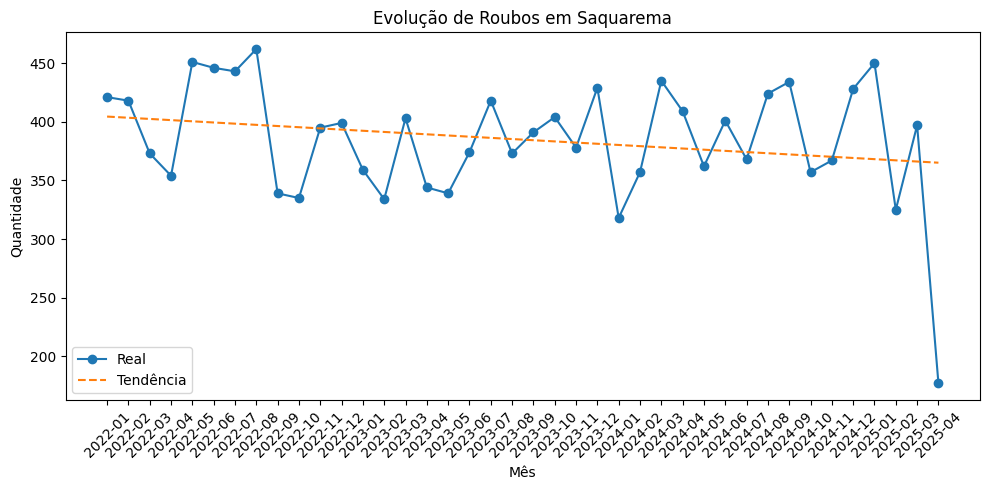

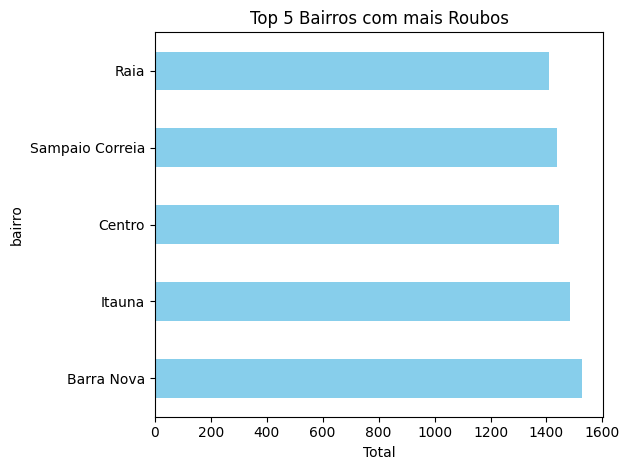

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

print("Lendo arquivo...")


# 1. LER O EXCEL

df = pd.read_excel("seguranca_saquarema_bigdata.xlsx")

# Padronizar colunas
df.columns = df.columns.str.strip().str.lower()

# Mostrar colunas (IMPORTANTE)
print("Colunas encontradas:", df.columns.tolist())


# 2. AJUSTES AUTOMÁTICOS


# Ajustar nome da coluna quantidade automaticamente (Agora mapeando 'ocorrencias')
for col in df.columns:
    if "quant" in col or "ocorrencias" in col:
        df = df.rename(columns={col: "quantidade"})

# Ajustar nome da coluna tipo automaticamente (Agora mapeando 'tipo_crime')
for col in df.columns:
    if "tipo" in col:
        df = df.rename(columns={col: "tipo"})

# Ajustar tipo
df["tipo"] = df["tipo"].astype(str).str.strip().str.lower()

# Ajustar data
df["data"] = pd.to_datetime(df["data"], errors="coerce")

# Remover dados inválidos
df = df.dropna(subset=["data", "quantidade"])

# Criar coluna mês/ano
df["mes"] = df["data"].dt.to_period("M")


# 3. FILTRO (ROUBOS)

# Verificando se existe o termo 'roubo' nos dados
df_roubo = df[df["tipo"].str.contains("roubo", na=False)]

# Agrupar por mês
df_mensal = df_roubo.groupby("mes")["quantidade"].sum().reset_index()

# Criar eixo tempo
df_mensal["tempo"] = np.arange(len(df_mensal))


# 4. INTELIGÊNCIA ARTIFICIAL

if not df_mensal.empty:
    X = df_mensal[["tempo"]]
    y = df_mensal["quantidade"]

    modelo = LinearRegression()
    modelo.fit(X, y)

    df_mensal["previsao"] = modelo.predict(X)

    print("\nPrecisão do modelo (R²):", round(modelo.score(X, y), 3))


    # 5. GRÁFICO PRINCIPAL

    plt.figure(figsize=(10,5))

    plt.plot(df_mensal["mes"].astype(str), y, label="Real", marker='o')
    plt.plot(df_mensal["mes"].astype(str), df_mensal["previsao"], linestyle="--", label="Tendência")

    plt.xticks(rotation=45)
    plt.title("Evolução de Roubos em Saquarema")
    plt.xlabel("Mês")
    plt.ylabel("Quantidade")
    plt.legend()
    plt.tight_layout()
    plt.show()


    # 6. TOP BAIRROS

    top_bairros = df_roubo.groupby("bairro")["quantidade"].sum().nlargest(5)

    plt.figure()
    top_bairros.plot(kind="barh", color='skyblue')

    plt.title("Top 5 Bairros com mais Roubos")
    plt.xlabel("Total")
    plt.tight_layout()
    plt.show()
else:
    print("Nenhum dado de 'roubo' encontrado para gerar os gráficos.")